# Trabajo 1 — Estadística Descriptiva
## Matrículas de Educación Superior — Región de Antofagasta, 2021

Integrantes: Boris Astudillo, Salvador Hurtado y Dennis Ponce

### Objetivo

Describir el conjunto de datos mediante tablas de frecuencia, gráficos estadísticos, medidas de tendencia central, percentiles y medidas de dispersión, interpretando los resultados dentro del contexto de los datos.

## Caso

Se dispone de una base de datos correspondiente a las matrículas de Educación Superior de la Región de Antofagasta durante el año 2021.

La base contiene información sobre género, edad, instituciones, carreras, áreas de conocimiento, duración de las carreras y valores de matrícula y arancel.

A partir de estos datos se realizará un análisis descriptivo y posteriormente se responderán tres preguntas relacionadas con los aranceles, la edad y el tipo de institución.

# 1. Comprender los datos

## 1.1 Población y muestra

Población: matrículas de Educación Superior de la Región de Antofagasta correspondientes al año 2021.

Muestra: 31.595 registros de matrícula contenidos en la base de datos proporcionada para el análisis.

In [1]:
import pandas as pd

# Carga de la base de datos
df = pd.read_excel('03_MATRICULAS_ED_SUPERIOR_ANTOFAGASTA_2021.xlsx')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31595 entries, 0 to 31594
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   ID                                       31595 non-null  int64  
 1   GENERO                                   31595 non-null  str    
 2   EDAD                                     31595 non-null  int64  
 3   RANGO EDAD                               31595 non-null  str    
 4   AÑO INGRESO                              31595 non-null  int64  
 5   SEMESTRE INGRESO                         31595 non-null  str    
 6   TIPO DE INSTITUCION                      31595 non-null  str    
 7   NOMBRE DE INSTITUCION                    31595 non-null  str    
 8   ACREDITACION INSTITUCIONAL               31595 non-null  str    
 9   PERIODO DE ACREDITACION                  29240 non-null  str    
 10  AÑOS DE ACREDITACION                     29240 non-null  

In [2]:
# Cantidad de registros
muestra = df.shape[0]
print("Cantidad de registros:", muestra)

Cantidad de registros: 31595


La base de datos contiene 31.595 registros de matrícula, que corresponden a los datos disponibles para realizar el análisis.

## 1.2 Exploración inicial de la base de datos

In [3]:
# Primeras cinco filas
df.head(5)

,ID,GENERO,EDAD,RANGO EDAD,AÑO INGRESO,SEMESTRE INGRESO,TIPO DE INSTITUCION,NOMBRE DE INSTITUCION,ACREDITACION INSTITUCIONAL,PERIODO DE ACREDITACION,...,NIVEL CARRERA,AREA CONOCIMIENTO,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS),REGION SEDE,PROVINCIA SEDE,COMUNA SEDE
0,53,Masculino,24,20 a 24,2018,Primer semestre,Universidades CRUCH,UNIVERSIDAD CATOLICA DEL NORTE,ACREDITADA,25/11/2016 AL 25/11/2022,...,Carreras Profesionales,Administracion y Comercio,10,2,10,142000,3696000,Antofagasta,Antofagasta,Antofagasta
1,64,Masculino,21,20 a 24,2019,Primer semestre,Institutos Profesionales,IP INACAP,ACREDITADA,11/12/2016 AL 11/12/2022,...,Carreras Profesionales,Tecnologia,8,0,8,220000,2176000,Antofagasta,El Loa,Calama
2,72,Masculino,23,20 a 24,2016,Primer semestre,Universidades CRUCH,UNIVERSIDAD CATOLICA DEL NORTE,ACREDITADA,25/11/2016 AL 25/11/2022,...,Carreras Profesionales,Administracion y Comercio,10,2,10,142000,4214000,Antofagasta,Antofagasta,Antofagasta
3,76,Femenino,18,15 a 19,2021,Primer semestre,Institutos Profesionales,IP INACAP,ACREDITADA,11/12/2016 AL 11/12/2022,...,Carreras Profesionales,Administracion y Comercio,8,0,8,220000,2016000,Antofagasta,El Loa,Calama
4,82,Masculino,19,15 a 19,2021,Primer semestre,Centros de Formacion Tecnica,CFT SANTO TOMAS,ACREDITADA,20/12/2019 AL 20/12/2024,...,Carreras Tecnicas,Salud,5,0,5,64000,2011000,Antofagasta,Antofagasta,Antofagasta


In [4]:
# Últimas cinco filas
df.tail(5)

,ID,GENERO,EDAD,RANGO EDAD,AÑO INGRESO,SEMESTRE INGRESO,TIPO DE INSTITUCION,NOMBRE DE INSTITUCION,ACREDITACION INSTITUCIONAL,PERIODO DE ACREDITACION,...,NIVEL CARRERA,AREA CONOCIMIENTO,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS),REGION SEDE,PROVINCIA SEDE,COMUNA SEDE
31590,1048394,Masculino,29,25 a 29,2021,Primer semestre,Institutos Profesionales,IP AIEP,ACREDITADA,22/10/2017 AL 22/10/2022,...,Carreras Tecnicas,Tecnologia,5,1,5,190000,1700000,Antofagasta,Antofagasta,Antofagasta
31591,1048415,Femenino,19,15 a 19,2021,Primer semestre,Institutos Profesionales,IP AIEP,ACREDITADA,22/10/2017 AL 22/10/2022,...,Carreras Tecnicas,Educacion,5,1,5,190000,1670000,Antofagasta,Antofagasta,Antofagasta
31592,1048419,Masculino,23,20 a 24,2017,Primer semestre,Universidades CRUCH,UNIVERSIDAD CATOLICA DEL NORTE,ACREDITADA,25/11/2016 AL 25/11/2022,...,Carreras Profesionales,Administracion y Comercio,10,2,10,142000,3696000,Antofagasta,Antofagasta,Antofagasta
31593,1048492,Masculino,21,20 a 24,2021,Primer semestre,Centros de Formacion Tecnica,CFT CEDUC - UCN,ACREDITADA,11/12/2015 AL 11/12/2020,...,Carreras Tecnicas,Tecnologia,5,0,5,112940,1672365,Antofagasta,Antofagasta,Antofagasta
31594,1048504,Femenino,39,35 a 39,2021,Primer semestre,Institutos Profesionales,IP INACAP,ACREDITADA,11/12/2016 AL 11/12/2022,...,Carreras Profesionales,Administracion y Comercio,8,0,8,220000,2016000,Antofagasta,El Loa,Calama


In [5]:
# Dimensiones de la base
df.shape

(31595, 28)

La base está compuesta por 31.595 registros y 28 variables. La información permite analizar características de las matrículas, instituciones, carreras, duración y valores económicos.

## 1.3 Variables seleccionadas

Para el análisis se seleccionaron variables cualitativas y cuantitativas relacionadas con la descripción de las matrículas y con las preguntas de investigación.

| Variable | Clasificación |
|---|---|
| `GENERO` | Cualitativa nominal |
| `TIPO DE INSTITUCION` | Cualitativa nominal |
| `AREA CONOCIMIENTO` | Cualitativa nominal |
| `EDAD` | Cuantitativa continua |
| `VALOR MATRICULA (PESOS)` | Cuantitativa continua |
| `VALOR ARANCEL (PESOS)` | Cuantitativa continua |
| `DURACION TOTAL CARRERA (SEMESTRES)` | Cuantitativa discreta |

Se consideran siete variables, de las cuales cuatro son cuantitativas. Entre ellas se incluyen variables continuas que permiten trabajar con intervalos, especialmente la edad y los valores monetarios.

### 1.4 Planificación del análisis

Para las variables cualitativas se utilizarán tablas de frecuencia y gráficos.

Para las variables cuantitativas se utilizarán tablas de frecuencia por intervalos, medidas de tendencia central, percentiles y medidas de dispersión.

Finalmente, se utilizarán las variables de la base para responder las tres preguntas de investigación.

## 1.5 Revisión de los datos

Antes de calcular estadísticos se revisa la calidad de la base: duplicados, valores nulos, formato de las categorías, consistencia entre variables y valores atípicos. Para cada hallazgo se indica si es un error que hay que corregir o una característica real de los datos.

### Duplicados

In [6]:
# Filas completamente repetidas
print("Filas duplicadas:", df.duplicated().sum())

# IDs repetidos (el ID identifica a cada matriculado)
print("IDs repetidos:", df['ID'].duplicated().sum())

Filas duplicadas: 0
IDs repetidos: 0


Interpretación:

No hay filas duplicadas ni IDs repetidos. Existen registros con las mismas características (por ejemplo, misma carrera, edad y género), pero tienen ID distinto, es decir, son estudiantes diferentes. Por lo tanto, no se elimina ningún registro.

### Valores nulos

In [7]:
# Cantidad de valores nulos por variable
nulos = df.isnull().sum()
nulos[nulos > 0]

PERIODO DE ACREDITACION    2355
AÑOS DE ACREDITACION       2355
dtype: int64

In [8]:
# ¿A qué instituciones corresponden los registros sin periodo de acreditación?
df[df['PERIODO DE ACREDITACION'].isnull()].groupby('ACREDITACION INSTITUCIONAL').size()

ACREDITACION INSTITUCIONAL
NO ACREDITADA    2355
dtype: int64

Interpretación:

Solo hay valores nulos en `PERIODO DE ACREDITACION` y `AÑOS DE ACREDITACION` (2.355 registros). Todos corresponden a instituciones **no acreditadas**: el dato no existe porque no aplica. No es un error y no se reemplaza por ningún valor. Además, estas variables no se usan en el análisis.

### Formato de las categorías

In [9]:
# Categorías de RANGO EDAD (se observan espacios al final de varias categorías)
df['RANGO EDAD'].unique()

<StringArray>
['20 a 24 ', '15 a 19 ', '35 a 39 ', '40 y mas', '30 a 34 ', '25 a 29 ']
Length: 6, dtype: str

In [10]:
# Se eliminan los espacios sobrantes al inicio y al final del texto
df['RANGO EDAD'] = df['RANGO EDAD'].str.strip()
df['RANGO EDAD'].unique()

<StringArray>
['20 a 24', '15 a 19', '35 a 39', '40 y mas', '30 a 34', '25 a 29']
Length: 6, dtype: str

Interpretación:

Varias categorías de `RANGO EDAD` tenían un espacio al final (por ejemplo `'20 a 24 '`). Es un error de formato, por lo que se corrige. La cantidad de registros de cada categoría no cambia.

### Consistencia entre variables: duración de la carrera

Se espera que la duración total sea igual a la duración del plan de estudio más la duración del proceso de titulación.

In [11]:
plan = df['DURACION PLAN DE ESTUDIO (SEMESTRES)']
titulacion = df['DURACION PROCESO TITULACION (SEMESTRES)']
total = df['DURACION TOTAL CARRERA (SEMESTRES)']

print("Registros donde total = plan + titulación:", (total == plan + titulacion).sum())
print("Registros donde total = plan:", (total == plan).sum())
print("Registros que no cumplen ninguna de las dos:", ((total != plan + titulacion) & (total != plan)).sum())

Registros donde total = plan + titulación: 13422
Registros donde total = plan: 31175
Registros que no cumplen ninguna de las dos: 0


Interpretación:

En muchos registros la duración total no es la suma del plan más la titulación. Sin embargo, según la descripción de las variables, la duración del plan no incluye la titulación solo cuando esta se realiza fuera del plan. Cuando la titulación está dentro del plan, la duración total es igual a la del plan. Todos los registros cumplen una de las dos formas, por lo que no es un error. En el análisis se usa la duración total.

### Valores atípicos y registros especiales

In [12]:
# Registros por nivel de estudio
df.groupby('NIVEL DE ESTUDIO CARRERA').size()

NIVEL DE ESTUDIO CARRERA
Postgrado      349
Postitulo      155
Pregrado     31091
dtype: int64

In [13]:
# Edad y arancel promedio por nivel de estudio
round(df.groupby('NIVEL DE ESTUDIO CARRERA')[['EDAD', 'VALOR ARANCEL (PESOS)']].mean(), 0)

,EDAD,VALOR ARANCEL (PESOS)
NIVEL DE ESTUDIO CARRERA,,
Postgrado,36.0,3384770.0
Postitulo,35.0,1551032.0
Pregrado,25.0,2766434.0


In [14]:
# Carrera con el arancel más alto de la base
df.sort_values('VALOR ARANCEL (PESOS)', ascending=False)[
    ['NOMBRE DE INSTITUCION', 'NOMBRE CARRERA', 'NIVEL DE ESTUDIO CARRERA', 'VALOR ARANCEL (PESOS)']
].head(3)

,NOMBRE DE INSTITUCION,NOMBRE CARRERA,NIVEL DE ESTUDIO CARRERA,VALOR ARANCEL (PESOS)
19084,UNIVERSIDAD CATOLICA DEL NORTE,MAGISTER EN GEOLOGIA ECONOMICA,Postgrado,8910265
20418,UNIVERSIDAD CATOLICA DEL NORTE,MAGISTER EN GEOLOGIA ECONOMICA,Postgrado,8910265
9413,UNIVERSIDAD CATOLICA DEL NORTE,MAGISTER EN GEOLOGIA ECONOMICA,Postgrado,8910265


In [15]:
# Registros con matrícula igual a $0, según institución
df[df['VALOR MATRICULA (PESOS)'] == 0].groupby('NOMBRE DE INSTITUCION').size()

NOMBRE DE INSTITUCION
CFT DE LA REGION DE ANTOFAGASTA    138
IP IPG                             131
UNIVERSIDAD CATOLICA DEL NORTE      90
UNIVERSIDAD SANTO TOMAS              2
dtype: int64

Interpretación:

- La base mezcla 31.091 registros de **pregrado** con 504 de **postgrado** (magíster y doctorado) y **postítulo** (diplomados). Estos últimos tienen estudiantes de mayor edad y otros aranceles.
- El arancel más alto (\$8.910.265) corresponde a un **Magíster en Geología Económica** de la UCN. Es un valor real, pero de un postgrado.
- Hay 361 registros con matrícula \$0 (CFT estatal, IP IPG y algunos diplomados). El valor es igual para todos los estudiantes de cada programa, por lo que corresponde a programas sin cobro de matrícula y no a un error.

Decisión: estos valores son reales, así que no se eliminan. En la descripción general (Ítem 1) se usa la base completa. En las preguntas de investigación se usa solo **pregrado**, porque las preguntas hablan de carreras y de ingreso a las instituciones.

### Unidad de análisis: ¿qué es una carrera?

Cada fila de la base es un **matriculado**, no una carrera. El arancel es una característica de la carrera, pero aparece repetido una vez por cada estudiante. Por eso, al promediar el arancel sobre todos los registros, las carreras con más estudiantes pesan más.

Además, el nombre de la carrera no basta para identificarla, porque una misma carrera se dicta en varias instituciones con aranceles distintos:

In [16]:
# Ejemplo: Ingeniería Comercial en distintas instituciones, sedes y jornadas
df[df['NOMBRE CARRERA'] == 'INGENIERIA COMERCIAL'].groupby(
    ['NOMBRE DE INSTITUCION', 'COMUNA SEDE', 'JORNADA']
)['VALOR ARANCEL (PESOS)'].mean()

NOMBRE DE INSTITUCION                    COMUNA SEDE  JORNADA   
UNIVERSIDAD ARTURO PRAT                  Antofagasta  Vespertino    3.433216e+06
UNIVERSIDAD CATOLICA DEL NORTE           Antofagasta  Diurno        4.214000e+06
UNIVERSIDAD SANTO TOMAS                  Antofagasta  Diurno        3.481000e+06
UNIVERSIDAD TECNOLOGICA DE CHILE INACAP  Antofagasta  Vespertino    2.478000e+06
                                         Calama       Vespertino    2.276000e+06
Name: VALOR ARANCEL (PESOS), dtype: float64

Interpretación:

Ingeniería Comercial cuesta \$4.214.000 en la UCN y cerca de \$2.300.000 en INACAP. Si se agrupara solo por nombre, se obtendría un promedio que no corresponde a ninguna carrera real.

Decisión: en este trabajo, una **carrera** es la combinación de **institución + nombre de la carrera + sede + jornada**, porque esa es la oferta concreta con su propio arancel.

# 2. Ítem 1 — Descripción general de los datos

En esta etapa se describen las variables seleccionadas mediante tablas de frecuencia, gráficos estadísticos, medidas de tendencia central, percentiles y medidas de dispersión.

## 2.1 Variable `GENERO`

La variable GENERO es cualitativa nominal, porque sus categorías no presentan un orden jerárquico.

In [17]:
# Frecuencia absoluta y relativa
cuenta_genero = df.groupby('GENERO').size()

tabla_genero = pd.DataFrame({
    'Frecuencia absoluta': cuenta_genero,
    'Frecuencia relativa (%)': round(cuenta_genero / muestra * 100, 1)
})

tabla_genero

,Frecuencia absoluta,Frecuencia relativa (%)
GENERO,,
Femenino,16088,50.9
Masculino,15507,49.1


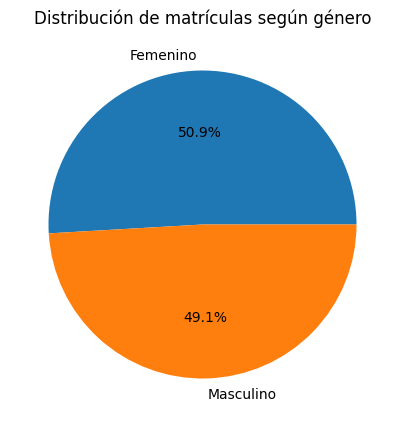

In [18]:
import matplotlib.pyplot as plt

# Evita que el signo $ de las etiquetas se interprete como fórmula matemática
plt.rcParams['text.parse_math'] = False

ETIQ = tabla_genero.index
FREC = tabla_genero['Frecuencia absoluta']

fig, ax = plt.subplots(figsize=(6,5))
ax.pie(FREC, labels=ETIQ, autopct='%.1f%%')
ax.set_title('Distribución de matrículas según género')
plt.show()

Interpretación:

Femenino: 16.088 registros (50,9%).
Masculino: 15.507 registros (49,1%).

Los porcentajes son muy similares. Esto indica que la cantidad de registros de mujeres y hombres es bastante equilibrada.

Se utiliza un gráfico de torta porque la variable tiene solo dos categorías y lo que interesa es mostrar qué parte del total representa cada una.

## 2.2 Variable `TIPO DE INSTITUCION`

La variable TIPO DE INSTITUCION es cualitativa nominal, porque sus categorías corresponden a distintos tipos de instituciones y no existe un orden entre ellas.

In [19]:
cuenta_institucion = df.groupby('TIPO DE INSTITUCION').size()

tabla_institucion = pd.DataFrame({
    'Frecuencia absoluta': cuenta_institucion,
    'Frecuencia relativa (%)': round(cuenta_institucion / muestra * 100, 1)
})

tabla_institucion

,Frecuencia absoluta,Frecuencia relativa (%)
TIPO DE INSTITUCION,,
Centros de Formacion Tecnica,4206,13.3
Institutos Profesionales,10073,31.9
Universidades CRUCH,12769,40.4
Universidades Privadas,4547,14.4


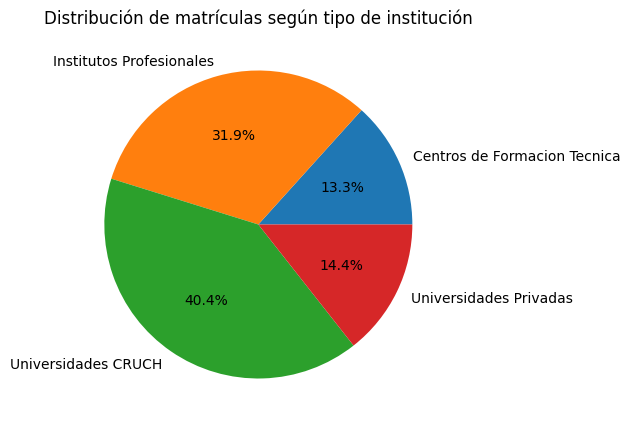

In [20]:
ETIQ = tabla_institucion.index
FREC = tabla_institucion['Frecuencia absoluta']

fig, ax = plt.subplots(figsize=(7,5))
ax.pie(FREC, labels=ETIQ, autopct='%.1f%%')
ax.set_title('Distribución de matrículas según tipo de institución')
plt.show()

Interpretación:

Universidades CRUCH: 12.769 registros (40,4%).
Institutos Profesionales: 10.073 registros (31,9%).
Universidades Privadas: 4.547 registros (14,4%).
Centros de Formación Técnica: 4.206 registros (13,3%).

El mayor número de registros corresponde a las Universidades CRUCH, con 12.769 registros. Los Institutos Profesionales ocupan el segundo lugar.

Se utiliza un gráfico de torta porque son pocas categorías (cuatro) y se busca mostrar la proporción de cada tipo sobre el total.

## 2.3 Variable `AREA CONOCIMIENTO`

La variable AREA CONOCIMIENTO es cualitativa nominal, ya que sus categorías representan diferentes áreas de conocimiento sin un orden jerárquico.

In [21]:
cuenta_area = df.groupby('AREA CONOCIMIENTO').size()

tabla_area = pd.DataFrame({
    'Frecuencia absoluta': cuenta_area,
    'Frecuencia relativa (%)': round(cuenta_area / muestra * 100, 1)
}).sort_values('Frecuencia absoluta', ascending=False)

tabla_area

,Frecuencia absoluta,Frecuencia relativa (%)
AREA CONOCIMIENTO,,
Tecnologia,11586,36.7
Administracion y Comercio,5669,17.9
Salud,5620,17.8
Educacion,2899,9.2
Ciencias Sociales,2448,7.7
Derecho,1300,4.1
Arte y Arquitectura,1034,3.3
Ciencias Basicas,971,3.1
Humanidades,68,0.2


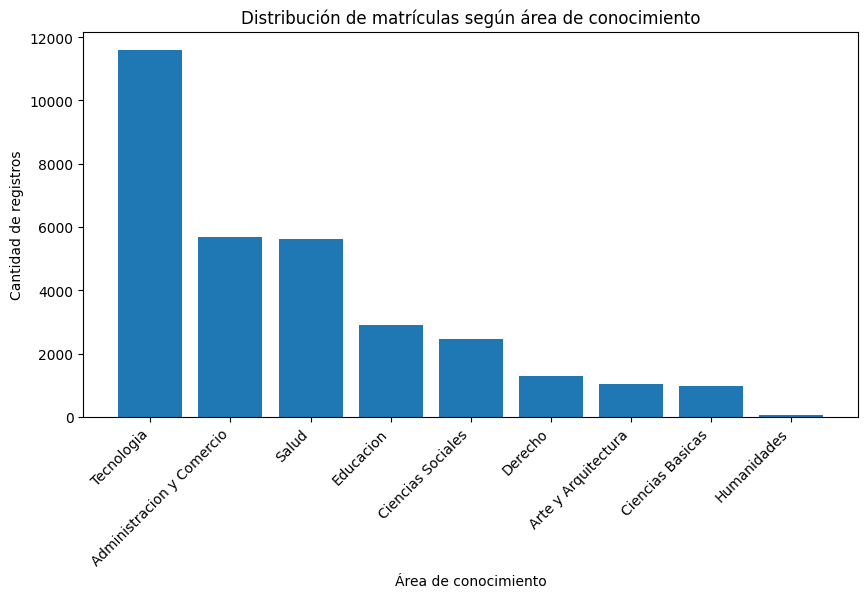

In [22]:
ETIQ = tabla_area.index
FREC = tabla_area['Frecuencia absoluta']

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(ETIQ, FREC)
ax.set_title('Distribución de matrículas según área de conocimiento')
ax.set_xlabel('Área de conocimiento')
ax.set_ylabel('Cantidad de registros')
plt.xticks(rotation=45, ha='right')
plt.show()

Interpretación:

Tecnología: 11.586 registros (36,7%).
Administración y Comercio: 5.669 registros (17,9%).
Salud: 5.620 registros (17,8%).

Tecnología es el área con más registros. Administración y Comercio y Salud presentan cantidades bastante menores, pero similares entre sí.

En este caso se utiliza un gráfico de barras porque hay nueve categorías, algunas muy pequeñas (Humanidades tiene 0,2%). En un gráfico de torta esas partes serían muy difíciles de comparar.

# 3. Análisis de las variables cuantitativas

Para las variables cuantitativas se utilizarán tablas de frecuencia por intervalos, medidas de tendencia central, percentiles y medidas de dispersión.

## 3.1 Variable `EDAD`

La variable EDAD es cuantitativa continua, de acuerdo con el criterio establecido para este curso. La edad puede tomar valores dentro de un intervalo y, por esta razón, se trabajará mediante intervalos.

In [23]:
# Creación de intervalos de edad de 5 años
limites_edad = [15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75]

etiquetas_edad = [
    '15 - 19', '20 - 24', '25 - 29', '30 - 34', '35 - 39', '40 - 44',
    '45 - 49', '50 - 54', '55 - 59', '60 - 64', '65 - 69', '70 - 74'
]

# right=False: cada intervalo incluye el límite inferior y excluye el superior (15 a 19, 20 a 24, ...)
df['Intervalos_edad'] = pd.cut(
    df['EDAD'],
    bins=limites_edad,
    labels=etiquetas_edad,
    right=False
)

cuenta_intervalos_edad = df.groupby(
    'Intervalos_edad',
    observed=False
).size()

tabla_edad = pd.DataFrame({
    'Frecuencia absoluta': cuenta_intervalos_edad,
    'Frecuencia absoluta acumulada': cuenta_intervalos_edad.cumsum(),
    'Frecuencia relativa (%)': cuenta_intervalos_edad / muestra * 100,
    'Frecuencia relativa acumulada (%)': (cuenta_intervalos_edad / muestra * 100).cumsum()
})

round(tabla_edad, 1)

,Frecuencia absoluta,Frecuencia absoluta acumulada,Frecuencia relativa (%),Frecuencia relativa acumulada (%)
Intervalos_edad,,,,
15 - 19,5156,5156,16.3,16.3
20 - 24,14485,19641,45.8,62.2
25 - 29,6018,25659,19.0,81.2
30 - 34,2870,28529,9.1,90.3
35 - 39,1537,30066,4.9,95.2
40 - 44,732,30798,2.3,97.5
45 - 49,493,31291,1.6,99.0
50 - 54,200,31491,0.6,99.7
55 - 59,74,31565,0.2,99.9


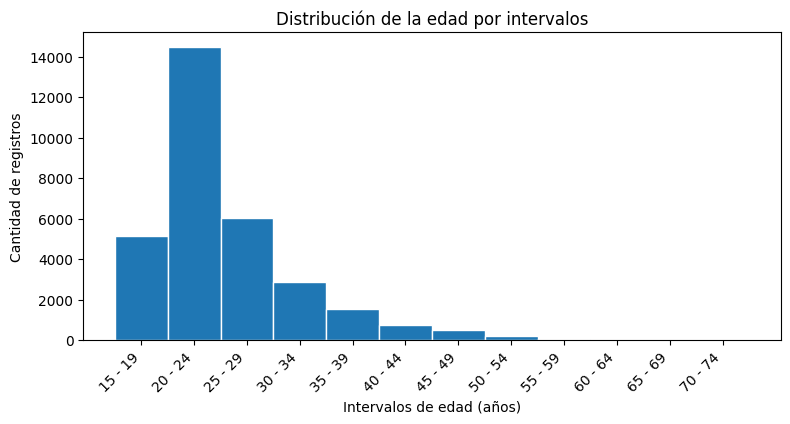

In [24]:
ETIQ = [str(i) for i in tabla_edad.index]
FREC = tabla_edad['Frecuencia absoluta']

fig, ax = plt.subplots(figsize=(9,4))
ax.bar(ETIQ, FREC, width=1, edgecolor='white')
ax.set_title('Distribución de la edad por intervalos')
ax.set_xlabel('Intervalos de edad (años)')
ax.set_ylabel('Cantidad de registros')
plt.xticks(rotation=45, ha='right')
plt.show()

Interpretación:

Se utilizan intervalos de 5 años con límites enteros, porque son más fáciles de interpretar que los intervalos con decimales y coinciden con la variable `RANGO EDAD` de la base. Las barras van juntas porque la edad se trata como una variable continua.

Intervalo de 20 a 24 años: 45,8% de los registros.
Intervalos de 15 a 24 años: 62,2% de los registros.
Hasta los 29 años: 81,2% de los registros.

La mayoría de los registros se concentra en edades jóvenes. A partir de los 30 años las frecuencias disminuyen, y hay pocos estudiantes de mucha mayor edad (hasta 72 años), lo que forma una cola hacia la derecha.

### Medidas de tendencia central de la edad

In [25]:
promedio_edad = df['EDAD'].mean()
mediana_edad = df['EDAD'].median()
moda_edad = df['EDAD'].mode()[0]

print("Promedio:", round(promedio_edad, 1))
print("Mediana:", mediana_edad)
print("Moda:", moda_edad)

Promedio: 25.4
Mediana: 23.0
Moda: 19


Interpretación:

Promedio: 25,4 años.
Mediana: 23 años.
Moda: 19 años.

La edad promedio es de 25,4 años. La mitad de los registros tiene 23 años o menos y la edad que más se repite es 19 años.

Se cumple moda < mediana < promedio. Esto indica una distribución asimétrica hacia la derecha: los pocos estudiantes de mayor edad aumentan el promedio. Por eso la mediana (23 años) representa mejor la edad típica de los matriculados.

### Percentiles de la edad

In [26]:
p25_edad = df['EDAD'].quantile(0.25)
p50_edad = df['EDAD'].quantile(0.50)
p75_edad = df['EDAD'].quantile(0.75)

print("P25:", p25_edad)
print("P50:", p50_edad)
print("P75:", p75_edad)

P25: 21.0
P50: 23.0
P75: 28.0


Interpretación:

P25: 21 años.
P50: 23 años.
P75: 28 años.

El 25% de los registros tiene 21 años o menos.
El 50% tiene 23 años o menos.
El 75% tiene 28 años o menos.

Esto muestra que la mayoría de los registros se concentra en edades relativamente jóvenes.

### Medidas de dispersión de la edad

In [27]:
rango_edad = df['EDAD'].max() - df['EDAD'].min()
varianza_edad = df['EDAD'].var()
desviacion_edad = df['EDAD'].std()
cv_edad = df['EDAD'].std() / df['EDAD'].mean() * 100

print("Rango:", rango_edad)
print("Varianza:", round(varianza_edad, 2))
print("Desviación estándar:", round(desviacion_edad, 2))
print("Coeficiente de variación (%):", round(cv_edad, 1))

Rango: 55
Varianza: 46.5
Desviación estándar: 6.82
Coeficiente de variación (%): 26.9


Interpretación:

Rango: 55 años.
Varianza: 46,5.
Desviación estándar: 6,8 años.
Coeficiente de variación: 26,9%.

La diferencia entre la edad mínima y máxima registrada es de 55 años. La desviación estándar indica que las edades se separan, en promedio, del valor central. El coeficiente de variación de 26,9% indica una dispersión relativa moderada.

## 3.2 Variable `VALOR MATRICULA (PESOS)`

La variable VALOR MATRICULA (PESOS) es cuantitativa continua para efectos del análisis, ya que corresponde a un valor monetario que puede variar en un rango de valores.

In [28]:
# Creación de intervalos de matrícula
limites_matricula = [0, 35625, 71250, 106875, 142500, 178125, 213750, 249375, 285000]

etiquetas_matricula = [
    '$0 - $35.625',
    '$35.625 - $71.250',
    '$71.250 - $106.875',
    '$106.875 - $142.500',
    '$142.500 - $178.125',
    '$178.125 - $213.750',
    '$213.750 - $249.375',
    '$249.375 - $285.000'
]

df['Intervalos_matricula'] = pd.cut(
    df['VALOR MATRICULA (PESOS)'],
    bins=limites_matricula,
    labels=etiquetas_matricula,
    include_lowest=True
)

cuenta_intervalos_matricula = df.groupby(
    'Intervalos_matricula',
    observed=True
).size()

tabla_matricula = pd.DataFrame({
    'Frecuencia absoluta': cuenta_intervalos_matricula,
    'Frecuencia absoluta acumulada': cuenta_intervalos_matricula.cumsum(),
    'Frecuencia relativa (%)': cuenta_intervalos_matricula / muestra * 100,
    'Frecuencia relativa acumulada (%)': (cuenta_intervalos_matricula / muestra * 100).cumsum()
})

round(tabla_matricula, 1)


,Frecuencia absoluta,Frecuencia absoluta acumulada,Frecuencia relativa (%),Frecuencia relativa acumulada (%)
Intervalos_matricula,,,,
$0 - $35.625,361,361,1.1,1.1
$35.625 - $71.250,1683,2044,5.3,6.5
$71.250 - $106.875,1284,3328,4.1,10.5
$106.875 - $142.500,9462,12790,29.9,40.5
$142.500 - $178.125,7082,19872,22.4,62.9
$178.125 - $213.750,5556,25428,17.6,80.5
$213.750 - $249.375,5961,31389,18.9,99.3
$249.375 - $285.000,206,31595,0.7,100.0


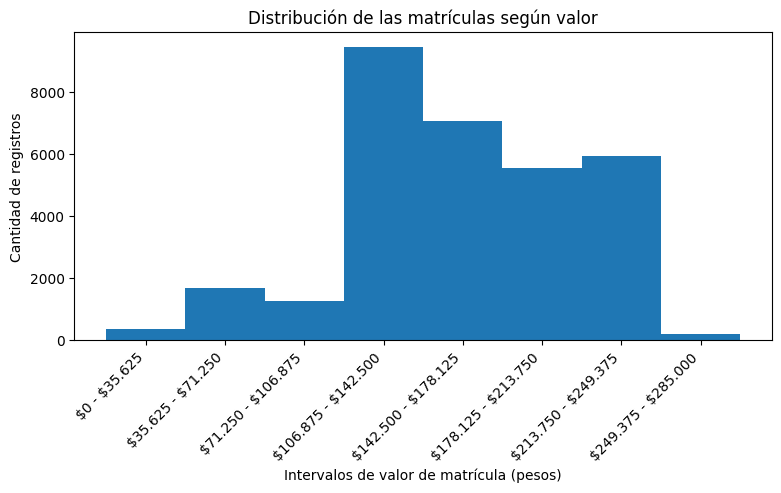

In [29]:
ETIQ = [str(i) for i in tabla_matricula.index]
FREC = tabla_matricula['Frecuencia absoluta']

fig, ax = plt.subplots(figsize=(9,4))
ax.bar(ETIQ, FREC, width=1)
ax.set_title('Distribución de las matrículas según valor')
ax.set_xlabel('Intervalos de valor de matrícula (pesos)')
ax.set_ylabel('Cantidad de registros')
plt.xticks(rotation=45, ha='right')
plt.show()

Interpretación:

Intervalo con más registros: \$106.875 - \$142.500.
Frecuencia relativa de ese intervalo: 29,9%.

Intervalos desde \$106.875 hasta \$249.375: 88,8% de los registros.

El intervalo más frecuente es el de \$106.875 a \$142.500. Además, al considerar los cuatro intervalos desde \$106.875 hasta \$249.375, se reúne el 88,8% de los registros.

El primer intervalo corresponde a los 361 registros con matrícula \$0, es decir, programas que no cobran matrícula.

### Medidas de tendencia central y percentiles de la matrícula

In [30]:
promedio_matricula = df['VALOR MATRICULA (PESOS)'].mean()
mediana_matricula = df['VALOR MATRICULA (PESOS)'].median()
moda_matricula = df['VALOR MATRICULA (PESOS)'].mode()[0]

p25_matricula = df['VALOR MATRICULA (PESOS)'].quantile(0.25)
p50_matricula = df['VALOR MATRICULA (PESOS)'].quantile(0.50)
p75_matricula = df['VALOR MATRICULA (PESOS)'].quantile(0.75)

print("Promedio:", round(promedio_matricula, 0))
print("Mediana:", mediana_matricula)
print("Moda:", moda_matricula)
print("P25:", p25_matricula)
print("P50:", p50_matricula)
print("P75:", p75_matricula)

Promedio: 160869.0
Mediana: 165000.0
Moda: 165000
P25: 142000.0
P50: 165000.0
P75: 190000.0


Interpretación:

Promedio: \$160.869.
Mediana: \$165.000.
Moda: \$165.000.
P25: \$142.000.
P50: \$165.000.
P75: \$190.000.

El valor promedio de matrícula es de \$160.869.
La mediana y la moda son de \$165.000, por lo que este valor representa el centro y el valor que más se repite.
El promedio es algo menor que la mediana porque los registros con matrícula \$0 bajan el promedio.
El 25% de los registros tiene una matrícula de \$142.000 o menos.
El 50% tiene una matrícula de \$165.000 o menos.
El 75% tiene una matrícula de \$190.000 o menos.

### Medidas de dispersión de la matrícula

In [31]:
rango_matricula = df['VALOR MATRICULA (PESOS)'].max() - df['VALOR MATRICULA (PESOS)'].min()
varianza_matricula = df['VALOR MATRICULA (PESOS)'].var()
desviacion_matricula = df['VALOR MATRICULA (PESOS)'].std()
cv_matricula = df['VALOR MATRICULA (PESOS)'].std() / df['VALOR MATRICULA (PESOS)'].mean() * 100

print("Rango:", rango_matricula)
print("Varianza:", round(varianza_matricula, 0))
print("Desviación estándar:", round(desviacion_matricula, 0))
print("Coeficiente de variación (%):", round(cv_matricula, 1))

Rango: 285000
Varianza: 2146687134.0
Desviación estándar: 46332.0
Coeficiente de variación (%): 28.8


Interpretación:

Rango: \$285.000.
Varianza: 2.146.687.134.
Desviación estándar: \$46.332.
Coeficiente de variación: 28,8%.

La diferencia entre la matrícula mínima y máxima es de \$285.000. La desviación estándar muestra que los valores de matrícula presentan variación alrededor del promedio. El coeficiente de variación es de 28,8%, lo que indica una dispersión relativa moderada.

## 3.3 Variable `VALOR ARANCEL (PESOS)`

La variable VALOR ARANCEL (PESOS) es cuantitativa continua para efectos del análisis, ya que corresponde a un valor monetario que puede variar en un rango de valores.

In [32]:
# Creación de intervalos de arancel de $1.000.000
limites_arancel = [0, 1000000, 2000000, 3000000, 4000000, 5000000, 6000000, 7000000, 8000000, 9000000]

etiquetas_arancel = [
    '$0 - $1M', '$1M - $2M', '$2M - $3M', '$3M - $4M', '$4M - $5M',
    '$5M - $6M', '$6M - $7M', '$7M - $8M', '$8M - $9M'
]

df['Intervalos_arancel'] = pd.cut(
    df['VALOR ARANCEL (PESOS)'],
    bins=limites_arancel,
    labels=etiquetas_arancel,
    include_lowest=True
)

# observed=False muestra también los intervalos sin registros
cuenta_intervalos_arancel = df.groupby(
    'Intervalos_arancel',
    observed=False
).size()

tabla_arancel = pd.DataFrame({
    'Frecuencia absoluta': cuenta_intervalos_arancel,
    'Frecuencia absoluta acumulada': cuenta_intervalos_arancel.cumsum(),
    'Frecuencia relativa (%)': cuenta_intervalos_arancel / muestra * 100,
    'Frecuencia relativa acumulada (%)': (cuenta_intervalos_arancel / muestra * 100).cumsum()
})

round(tabla_arancel, 1)

,Frecuencia absoluta,Frecuencia absoluta acumulada,Frecuencia relativa (%),Frecuencia relativa acumulada (%)
Intervalos_arancel,,,,
$0 - $1M,64,64,0.2,0.2
$1M - $2M,8550,8614,27.1,27.3
$2M - $3M,10552,19166,33.4,60.7
$3M - $4M,8362,27528,26.5,87.1
$4M - $5M,3407,30935,10.8,97.9
$5M - $6M,651,31586,2.1,100.0
$6M - $7M,0,31586,0.0,100.0
$7M - $8M,0,31586,0.0,100.0
$8M - $9M,9,31595,0.0,100.0


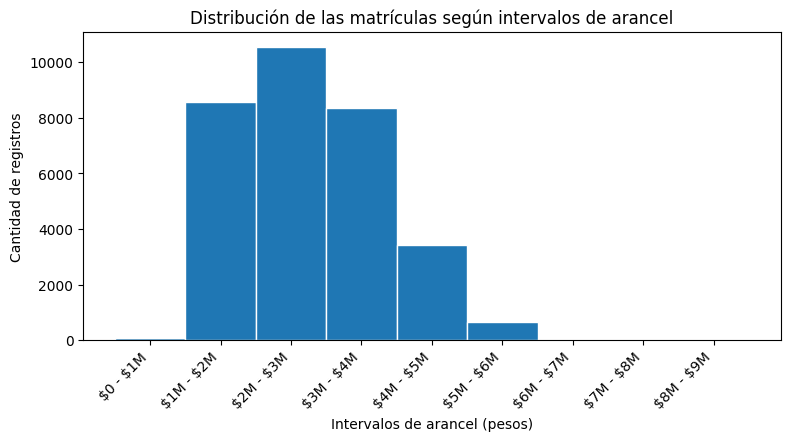

In [33]:
ETIQ = [str(i) for i in tabla_arancel.index]
FREC = tabla_arancel['Frecuencia absoluta']

fig, ax = plt.subplots(figsize=(9,4))
ax.bar(ETIQ, FREC, width=1, edgecolor='white')
ax.set_title('Distribución de las matrículas según intervalos de arancel')
ax.set_xlabel('Intervalos de arancel (pesos)')
ax.set_ylabel('Cantidad de registros')
plt.xticks(rotation=45, ha='right')
plt.show()

Interpretación:

Se utilizan intervalos de \$1.000.000 porque tienen límites fáciles de leer. Se muestran también los intervalos vacíos, ya que forman parte de la distribución.

Intervalo con más registros: \$2M - \$3M (33,4%).
Intervalos desde \$1M hasta \$4M: 86,9% de los registros.

Los intervalos de \$6M a \$8M no tienen registros. Los 9 registros del último intervalo corresponden al Magíster en Geología Económica (\$8.910.265), que queda separado del resto de los valores.

### Medidas de tendencia central y percentiles del arancel

In [34]:
promedio_arancel = df['VALOR ARANCEL (PESOS)'].mean()
mediana_arancel = df['VALOR ARANCEL (PESOS)'].median()
moda_arancel = df['VALOR ARANCEL (PESOS)'].mode()[0]

p25_arancel = df['VALOR ARANCEL (PESOS)'].quantile(0.25)
p50_arancel = df['VALOR ARANCEL (PESOS)'].quantile(0.50)
p75_arancel = df['VALOR ARANCEL (PESOS)'].quantile(0.75)

print("Promedio:", round(promedio_arancel, 0))
print("Mediana:", mediana_arancel)
print("Moda:", moda_arancel)
print("P25:", p25_arancel)
print("P50:", p50_arancel)
print("P75:", p75_arancel)

Promedio: 2767302.0
Mediana: 2318000.0
Moda: 3676000
P25: 1892000.0
P50: 2318000.0
P75: 3676000.0


Interpretación:

Promedio: \$2.767.302.
Mediana: \$2.318.000.
Moda: \$3.676.000.
P25: \$1.892.000.
P50: \$2.318.000.
P75: \$3.676.000.

El arancel promedio es de \$2.767.302.
La mitad de los registros tiene un arancel de \$2.318.000 o menos.
El 25% tiene un arancel de \$1.892.000 o menos.
El 75% tiene un arancel de \$3.676.000 o menos.
La moda es \$3.676.000, que corresponde al valor que más se repite.

### Medidas de dispersión del arancel

In [35]:
rango_arancel = df['VALOR ARANCEL (PESOS)'].max() - df['VALOR ARANCEL (PESOS)'].min()
varianza_arancel = df['VALOR ARANCEL (PESOS)'].var()
desviacion_arancel = df['VALOR ARANCEL (PESOS)'].std()
cv_arancel = df['VALOR ARANCEL (PESOS)'].std() / df['VALOR ARANCEL (PESOS)'].mean() * 100

print("Rango:", rango_arancel)
print("Varianza:", round(varianza_arancel, 0))
print("Desviación estándar:", round(desviacion_arancel, 0))
print("Coeficiente de variación (%):", round(cv_arancel, 1))

Rango: 8560265
Varianza: 1014325338097.0
Desviación estándar: 1007137.0
Coeficiente de variación (%): 36.4


Interpretación:

Rango: \$8.560.265.
Varianza: 1.014.325.338.097.
Desviación estándar: \$1.007.137.
Coeficiente de variación: 36,4%.

La diferencia entre el arancel mínimo y máximo es de \$8.560.265. La desviación estándar muestra una variación considerable entre los valores de arancel. El coeficiente de variación de 36,4% indica una dispersión relativa mayor que la observada en edad y matrícula.

### Arancel por matriculado y por carrera

El promedio anterior considera cada **registro**: es el arancel que enfrenta un matriculado. Como las carreras con más estudiantes pesan más, también se calcula el promedio considerando cada **carrera** una sola vez.

In [36]:
# Arancel de cada carrera (institución + nombre + sede + jornada)
arancel_carreras = df.groupby(
    ['NOMBRE DE INSTITUCION', 'NOMBRE CARRERA', 'COMUNA SEDE', 'JORNADA']
)['VALOR ARANCEL (PESOS)'].mean()

print("Cantidad de carreras:", arancel_carreras.shape[0])
print("Arancel promedio por matriculado:", round(df['VALOR ARANCEL (PESOS)'].mean(), 0))
print("Arancel promedio por carrera:", round(arancel_carreras.mean(), 0))

Cantidad de carreras: 519
Arancel promedio por matriculado: 2767302.0
Arancel promedio por carrera: 2365188.0


Interpretación:

Arancel promedio por matriculado: \$2.767.302.
Arancel promedio por carrera: \$2.365.188.

El promedio por carrera es \$402.114 menor. Esto ocurre porque las carreras más caras (principalmente de universidades CRUCH) tienen más estudiantes y, al contar registros, pesan más en el promedio. Ambos valores son correctos, pero responden preguntas distintas.

## 3.4 Variable `DURACION TOTAL CARRERA (SEMESTRES)`

La variable DURACION TOTAL CARRERA (SEMESTRES) es cuantitativa discreta, porque se expresa mediante una cantidad determinada de semestres.

In [37]:
# Frecuencia por cada valor de duración (no se usan intervalos porque la variable es discreta)
cuenta_duracion = df.groupby('DURACION TOTAL CARRERA (SEMESTRES)').size()

tabla_duracion = pd.DataFrame({
    'Frecuencia absoluta': cuenta_duracion,
    'Frecuencia absoluta acumulada': cuenta_duracion.cumsum(),
    'Frecuencia relativa (%)': cuenta_duracion / muestra * 100,
    'Frecuencia relativa acumulada (%)': (cuenta_duracion / muestra * 100).cumsum()
})

round(tabla_duracion, 1)

,Frecuencia absoluta,Frecuencia absoluta acumulada,Frecuencia relativa (%),Frecuencia relativa acumulada (%)
DURACION TOTAL CARRERA (SEMESTRES),,,,
1,2,2,0.0,0.0
2,201,203,0.6,0.6
3,52,255,0.2,0.8
4,2790,3045,8.8,9.6
5,7205,10250,22.8,32.4
6,63,10313,0.2,32.6
7,8,10321,0.0,32.7
8,7927,18248,25.1,57.8
9,1005,19253,3.2,60.9


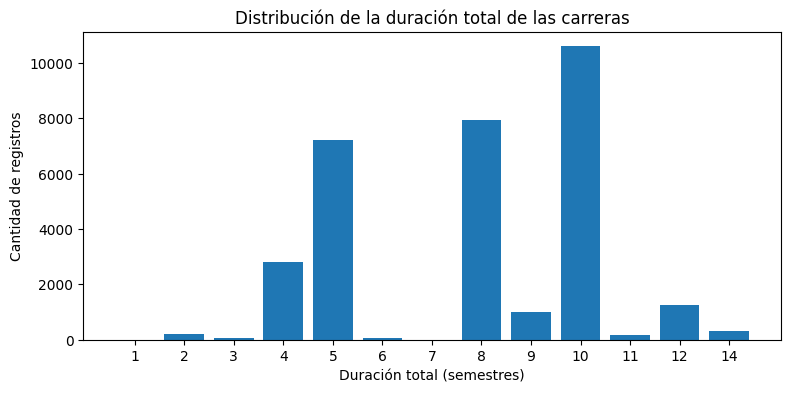

In [38]:
ETIQ = [str(i) for i in tabla_duracion.index]
FREC = tabla_duracion['Frecuencia absoluta']

fig, ax = plt.subplots(figsize=(9,4))
ax.bar(ETIQ, FREC)
ax.set_title('Distribución de la duración total de las carreras')
ax.set_xlabel('Duración total (semestres)')
ax.set_ylabel('Cantidad de registros')
plt.show()

Interpretación:

Como la duración es una variable discreta y toma pocos valores enteros, se construye la tabla con la frecuencia de cada valor en lugar de usar intervalos. Por eso las barras del gráfico van separadas.

10 semestres: 33,5% de los registros (valor más frecuente).
8 semestres: 25,1%.
5 semestres: 22,8%.

Se observan dos grupos: carreras técnicas de 4 a 5 semestres (31,6%) y carreras profesionales de 8 a 10 semestres (61,8%). Entre ambos grupos casi no hay registros (6 y 7 semestres suman solo 71 registros).

### Medidas de tendencia central y percentiles de la duración

In [39]:
promedio_duracion = df['DURACION TOTAL CARRERA (SEMESTRES)'].mean()
mediana_duracion = df['DURACION TOTAL CARRERA (SEMESTRES)'].median()
moda_duracion = df['DURACION TOTAL CARRERA (SEMESTRES)'].mode()[0]

p25_duracion = df['DURACION TOTAL CARRERA (SEMESTRES)'].quantile(0.25)
p50_duracion = df['DURACION TOTAL CARRERA (SEMESTRES)'].quantile(0.50)
p75_duracion = df['DURACION TOTAL CARRERA (SEMESTRES)'].quantile(0.75)

print("Promedio:", round(promedio_duracion, 1))
print("Mediana:", mediana_duracion)
print("Moda:", moda_duracion)
print("P25:", p25_duracion)
print("P50:", p50_duracion)
print("P75:", p75_duracion)

Promedio: 7.9
Mediana: 8.0
Moda: 10
P25: 5.0
P50: 8.0
P75: 10.0


Interpretación:

Promedio: 7,9 semestres.
Mediana: 8 semestres.
Moda: 10 semestres.
P25: 5 semestres.
P50: 8 semestres.
P75: 10 semestres.

La duración promedio es de 7,9 semestres y la mediana es de 8 semestres.
El 25% de los registros tiene una duración de 5 semestres o menos.
El 50% tiene una duración de 8 semestres o menos.
El 75% tiene una duración de 10 semestres o menos.
La duración que más se repite es de 10 semestres.

Como la distribución tiene dos grupos, el promedio (7,9) queda en una zona con muy pocos registros, por lo que no representa bien a una carrera típica.

### Medidas de dispersión de la duración

In [40]:
rango_duracion = df['DURACION TOTAL CARRERA (SEMESTRES)'].max() - df['DURACION TOTAL CARRERA (SEMESTRES)'].min()
varianza_duracion = df['DURACION TOTAL CARRERA (SEMESTRES)'].var()
desviacion_duracion = df['DURACION TOTAL CARRERA (SEMESTRES)'].std()
cv_duracion = df['DURACION TOTAL CARRERA (SEMESTRES)'].std() / df['DURACION TOTAL CARRERA (SEMESTRES)'].mean() * 100

print("Rango:", rango_duracion)
print("Varianza:", round(varianza_duracion, 2))
print("Desviación estándar:", round(desviacion_duracion, 2))
print("Coeficiente de variación (%):", round(cv_duracion, 1))

Rango: 13
Varianza: 6.15
Desviación estándar: 2.48
Coeficiente de variación (%): 31.6


Interpretación:

Rango: 13 semestres.
Varianza: 6,15.
Desviación estándar: 2,5 semestres.
Coeficiente de variación: 31,6%.

La diferencia entre la duración mínima y máxima es de 13 semestres. La desviación estándar muestra que las duraciones presentan variación alrededor del promedio. El coeficiente de variación es de 31,6%, por lo que la duración presenta una dispersión relativa mayor que la edad y la matrícula.

In [41]:
# Duración promedio considerando cada carrera una sola vez
duracion_carreras = df.groupby(
    ['NOMBRE DE INSTITUCION', 'NOMBRE CARRERA', 'COMUNA SEDE', 'JORNADA']
)['DURACION TOTAL CARRERA (SEMESTRES)'].mean()

print("Duración promedio por matriculado:", round(df['DURACION TOTAL CARRERA (SEMESTRES)'].mean(), 1))
print("Duración promedio por carrera:", round(duracion_carreras.mean(), 1))
print("Duración mediana por carrera:", duracion_carreras.median())

Duración promedio por matriculado: 7.9
Duración promedio por carrera: 6.6
Duración mediana por carrera: 5.0


Interpretación:

Un matriculado cursa, en promedio, una carrera de 7,9 semestres, pero la carrera promedio dura 6,6 semestres (mediana 5). Las carreras largas concentran más estudiantes.

## 3.5 Otros resúmenes

Se utiliza `describe()` para obtener un resumen general de las cuatro variables cuantitativas analizadas.

In [42]:
df[
    ['EDAD',
     'VALOR MATRICULA (PESOS)',
     'VALOR ARANCEL (PESOS)',
     'DURACION TOTAL CARRERA (SEMESTRES)']
].describe()

,EDAD,VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS),DURACION TOTAL CARRERA (SEMESTRES)
count,31595.000000,31595.000000,3.159500e+04,31595.000000
mean,25.365691,160869.022314,2.767302e+06,7.850578
std,6.818984,46332.355148,1.007137e+06,2.480535
min,17.000000,0.000000,3.500000e+05,1.000000
25%,21.000000,142000.000000,1.892000e+06,5.000000
50%,23.000000,165000.000000,2.318000e+06,8.000000
75%,28.000000,190000.000000,3.676000e+06,10.000000
max,72.000000,285000.000000,8.910265e+06,14.000000


# 4. Ítem 2 — Preguntas de investigación

A continuación se responden las tres preguntas planteadas en el trabajo, definiendo en cada caso el criterio utilizado.

Antes de calcular, se define la **unidad de análisis** de cada pregunta, es decir, qué se está contando:

| Pregunta | ¿Sobre qué pregunta? | Unidad de análisis |
|---|---|---|
| 1. Áreas con carreras más caras | Carreras | Cada carrera cuenta una vez |
| 2. Edad y tipo de institución | Estudiantes | Cada matriculado cuenta una vez |
| 3. Carreras sustancialmente más caras | Carreras | Cada carrera cuenta una vez |

En las tres preguntas se usan solo los registros de **pregrado**.

In [43]:
# Se consideran los registros de nivel de estudio Pregrado
df_pregrado = df[
    df['NIVEL DE ESTUDIO CARRERA'] == 'Pregrado'
]

print("Registros de pregrado:", df_pregrado.shape[0])

Registros de pregrado: 31091


## Pregunta 1

### ¿Hay áreas del conocimiento donde las carreras son más caras? ¿Qué criterio se diseñó para responder?

Las áreas están formadas por carreras, no por matriculados. Si se promedia el arancel sobre todos los registros, cada carrera pesa según su número de estudiantes. Por eso el criterio es:

1. Calcular el arancel de cada carrera de pregrado.
2. Calcular el arancel promedio de las carreras de cada área.
3. Comparar ese valor con el arancel promedio de todas las carreras de pregrado.

Se considera que un área tiene carreras más caras cuando su promedio es superior al promedio general de las carreras.

In [44]:
# Paso 1: arancel de cada carrera (institución + nombre + sede + jornada), incluyendo su área
carreras = df_pregrado.groupby(
    ['NOMBRE DE INSTITUCION', 'NOMBRE CARRERA', 'COMUNA SEDE', 'JORNADA', 'AREA CONOCIMIENTO']
)[
    ['VALOR ARANCEL (PESOS)',
     'DURACION TOTAL CARRERA (SEMESTRES)']
].mean()

# reset_index convierte los nombres de los grupos en columnas, para poder volver a agrupar
carreras = carreras.reset_index()

print("Cantidad de carreras de pregrado:", carreras.shape[0])
carreras.head()

Cantidad de carreras de pregrado: 466


,NOMBRE DE INSTITUCION,NOMBRE CARRERA,COMUNA SEDE,JORNADA,AREA CONOCIMIENTO,VALOR ARANCEL (PESOS),DURACION TOTAL CARRERA (SEMESTRES)
0,CFT CEDUC - UCN,ADMINISTRACION BILINGUE,Antofagasta,Diurno,Administracion y Comercio,1672365.0,5.0
1,CFT CEDUC - UCN,ADMINISTRACION BILINGUE,Antofagasta,Vespertino,Administracion y Comercio,1672365.0,5.0
2,CFT CEDUC - UCN,COMPUTACION E INFORMATICA,Antofagasta,Diurno,Tecnologia,1672365.0,5.0
3,CFT CEDUC - UCN,COMPUTACION E INFORMATICA,Antofagasta,Vespertino,Tecnologia,1672365.0,5.0
4,CFT CEDUC - UCN,EDUCACION DE PARVULOS,Antofagasta,Diurno,Educacion,1672365.0,5.0


In [45]:
# Paso 2: promedio y mediana del arancel de las carreras de cada área
promedio_area = carreras.groupby('AREA CONOCIMIENTO')['VALOR ARANCEL (PESOS)'].mean()
mediana_area = carreras.groupby('AREA CONOCIMIENTO')['VALOR ARANCEL (PESOS)'].median()
cantidad_carreras_area = carreras.groupby('AREA CONOCIMIENTO').size()

resultado_pregunta_1 = pd.DataFrame({
    'Arancel promedio': promedio_area,
    'Arancel mediana': mediana_area,
    'Cantidad de carreras': cantidad_carreras_area
}).sort_values(
    'Arancel promedio',
    ascending=False
)

round(resultado_pregunta_1, 0)

,Arancel promedio,Arancel mediana,Cantidad de carreras
AREA CONOCIMIENTO,,,
Ciencias Basicas,3289947.0,3366500.0,14
Derecho,2942766.0,2910000.0,10
Salud,2722862.0,2250000.0,56
Tecnologia,2354266.0,2176000.0,200
Arte y Arquitectura,2299846.0,1890000.0,13
Ciencias Sociales,2264427.0,1790954.0,26
Administracion y Comercio,2034664.0,1860000.0,96
Educacion,1918151.0,1700000.0,47
Humanidades,1713250.0,1452000.0,4


In [46]:
# Paso 3: comparación con el promedio general de las carreras
promedio_general_carreras = carreras['VALOR ARANCEL (PESOS)'].mean()
print("Arancel promedio general de las carreras:", round(promedio_general_carreras, 0))

areas_mayor_promedio = resultado_pregunta_1[
    resultado_pregunta_1['Arancel promedio'] > promedio_general_carreras
]

round(areas_mayor_promedio, 0)

Arancel promedio general de las carreras: 2317441.0


,Arancel promedio,Arancel mediana,Cantidad de carreras
AREA CONOCIMIENTO,,,
Ciencias Basicas,3289947.0,3366500.0,14
Derecho,2942766.0,2910000.0,10
Salud,2722862.0,2250000.0,56
Tecnologia,2354266.0,2176000.0,200


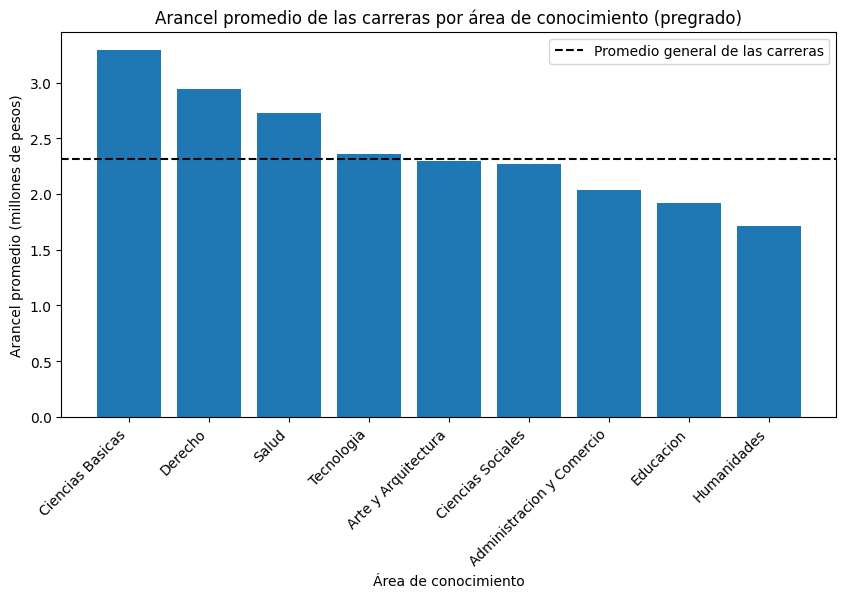

In [47]:
ETIQ = resultado_pregunta_1.index
FREC = resultado_pregunta_1['Arancel promedio'] / 1000000   # en millones de pesos

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(ETIQ, FREC)
ax.axhline(promedio_general_carreras / 1000000, color='black', linestyle='--', label='Promedio general de las carreras')
ax.set_title('Arancel promedio de las carreras por área de conocimiento (pregrado)')
ax.set_xlabel('Área de conocimiento')
ax.set_ylabel('Arancel promedio (millones de pesos)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.show()

### Comparación con el criterio anterior (por matriculado)

Para mostrar por qué importa el criterio, se calcula también el promedio por matriculado, que fue el criterio usado en la primera versión del trabajo.

In [48]:
promedio_area_matriculado = df_pregrado.groupby('AREA CONOCIMIENTO')['VALOR ARANCEL (PESOS)'].mean()
promedio_general_matriculado = df_pregrado['VALOR ARANCEL (PESOS)'].mean()

comparacion = pd.DataFrame({
    'Por matriculado': promedio_area_matriculado,
    'Diferencia con el promedio, por matriculado (%)': (promedio_area_matriculado / promedio_general_matriculado - 1) * 100,
    'Por carrera': promedio_area,
    'Diferencia con el promedio, por carrera (%)': (promedio_area / promedio_general_carreras - 1) * 100
}).sort_values('Por carrera', ascending=False)

print("Promedio general por matriculado:", round(promedio_general_matriculado, 0))
print("Promedio general por carrera:", round(promedio_general_carreras, 0))
round(comparacion, 1)

Promedio general por matriculado: 2766434.0
Promedio general por carrera: 2317441.0


,Por matriculado,"Diferencia con el promedio, por matriculado (%)",Por carrera,"Diferencia con el promedio, por carrera (%)"
AREA CONOCIMIENTO,,,,
Ciencias Basicas,3689986.3,33.4,3289946.7,42.0
Derecho,3663877.3,32.4,2942765.6,27.0
Salud,3286602.0,18.8,2722862.0,17.5
Tecnologia,2690476.5,-2.7,2354265.7,1.6
Arte y Arquitectura,3012945.5,8.9,2299846.2,-0.8
Ciencias Sociales,2831503.5,2.4,2264426.6,-2.3
Administracion y Comercio,2345936.0,-15.2,2034664.4,-12.2
Educacion,2039715.9,-26.3,1918150.9,-17.2
Humanidades,2057666.7,-25.6,1713250.0,-26.1


Interpretación:

Arancel promedio general de las 466 carreras de pregrado: \$2.317.441.

Áreas sobre el promedio general (por carrera):

Ciencias Básicas: \$3.289.947 (+42,0%).
Derecho: \$2.942.766 (+27,0%).
Salud: \$2.722.862 (+17,5%).
Tecnología: \$2.354.266 (+1,6%).

**Cambio respecto al criterio anterior.** Por matriculado, Tecnología tenía un promedio de \$2.690.477, un 2,7% bajo el promedio general por matriculado (\$2.766.434). Por carrera, queda un 1,6% sobre el promedio. Tecnología cambia de lado porque el promedio general baja mucho al contar carreras (\$448.993 menos): hay muchas carreras técnicas de CFT e IP, con pocos estudiantes cada una y aranceles bajos.

**Conclusión.** Ciencias Básicas, Derecho y Salud tienen carreras más caras que el promedio con ambos criterios, y también tienen las medianas más altas. Tecnología (+1,6%) y Arte y Arquitectura (−0,8%) están prácticamente en el promedio, por lo que no se puede afirmar que sean áreas caras o baratas. Derecho (10 carreras) y Ciencias Básicas (14) tienen pocas carreras, lo que hace sus promedios menos estables.

## Pregunta 2

### ¿Qué influencia tiene la edad en el tipo de institución a la que ingresan los estudiantes?

Aquí la pregunta es sobre los **estudiantes**, por lo que la unidad de análisis es el matriculado.

La pregunta habla de la edad al **ingresar**. Si se usa la edad actual de todos los matriculados, se mezcla la edad de ingreso con los años que cada estudiante lleva estudiando (en las universidades, con carreras largas, los estudiantes de cursos superiores tienen más edad). Por eso se usan los estudiantes de pregrado que **ingresaron en 2021**, cuya edad corresponde a la edad de ingreso.

Se calcula la media y la mediana de edad para cada tipo de institución. El análisis es descriptivo: permite observar una asociación entre las variables, pero no permite afirmar que la edad sea la causa de la elección.

In [49]:
# Estudiantes de pregrado que ingresaron en 2021
df_ingreso_2021 = df_pregrado[
    df_pregrado['AÑO INGRESO'] == 2021
]

print("Estudiantes de pregrado que ingresaron en 2021:", df_ingreso_2021.shape[0])

Estudiantes de pregrado que ingresaron en 2021: 9393


In [50]:
promedio_edad_institucion = df_ingreso_2021.groupby(
    'TIPO DE INSTITUCION'
)['EDAD'].mean()

mediana_edad_institucion = df_ingreso_2021.groupby(
    'TIPO DE INSTITUCION'
)['EDAD'].median()

# Porcentaje de estudiantes que ingresan con 25 años o más en cada tipo
mayores_25 = df_ingreso_2021[df_ingreso_2021['EDAD'] >= 25].groupby('TIPO DE INSTITUCION').size()
total_tipo = df_ingreso_2021.groupby('TIPO DE INSTITUCION').size()

resultado_pregunta_2 = pd.DataFrame({
    'Edad promedio': promedio_edad_institucion,
    'Edad mediana': mediana_edad_institucion,
    'Ingresan con 25 años o más (%)': mayores_25 / total_tipo * 100,
    'Cantidad de estudiantes': total_tipo
}).sort_values(
    'Edad promedio'
)

round(resultado_pregunta_2, 1)

,Edad promedio,Edad mediana,Ingresan con 25 años o más (%),Cantidad de estudiantes
TIPO DE INSTITUCION,,,,
Universidades CRUCH,21.8,19.0,16.8,2317
Centros de Formacion Tecnica,24.7,22.0,35.0,1959
Institutos Profesionales,25.8,23.0,42.5,3840
Universidades Privadas,26.9,24.0,47.5,1277


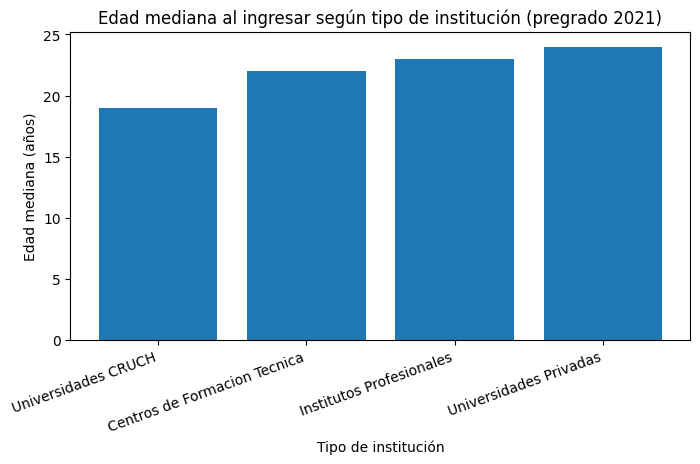

In [51]:
ETIQ = resultado_pregunta_2.index
FREC = resultado_pregunta_2['Edad mediana']

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(ETIQ, FREC)
ax.set_title('Edad mediana al ingresar según tipo de institución (pregrado 2021)')
ax.set_xlabel('Tipo de institución')
ax.set_ylabel('Edad mediana (años)')
plt.xticks(rotation=20, ha='right')
plt.show()

### Comparación con el criterio anterior (edad actual de todos los matriculados)

In [52]:
promedio_edad_todos = df.groupby('TIPO DE INSTITUCION')['EDAD'].mean()
mediana_edad_todos = df.groupby('TIPO DE INSTITUCION')['EDAD'].median()

comparacion_edad = pd.DataFrame({
    'Promedio (todos, edad actual)': promedio_edad_todos,
    'Mediana (todos, edad actual)': mediana_edad_todos,
    'Promedio (ingreso 2021)': promedio_edad_institucion,
    'Mediana (ingreso 2021)': mediana_edad_institucion
}).sort_values('Promedio (ingreso 2021)')

round(comparacion_edad, 1)

,"Promedio (todos, edad actual)","Mediana (todos, edad actual)",Promedio (ingreso 2021),Mediana (ingreso 2021)
TIPO DE INSTITUCION,,,,
Universidades CRUCH,23.8,23.0,21.8,19.0
Centros de Formacion Tecnica,25.0,23.0,24.7,22.0
Institutos Profesionales,26.8,24.0,25.8,23.0
Universidades Privadas,27.0,24.0,26.9,24.0


Interpretación:

Universidades CRUCH: promedio 21,8 años; mediana 19 años.
Centros de Formación Técnica: promedio 24,7 años; mediana 22 años.
Institutos Profesionales: promedio 25,8 años; mediana 23 años.
Universidades Privadas: promedio 26,9 años; mediana 24 años.

En las Universidades CRUCH la mayoría de los estudiantes ingresa directamente después de la enseñanza media (mediana de 19 años) y solo el 16,8% ingresa con 25 años o más. En las Universidades Privadas (47,5%) y en los Institutos Profesionales (42,5%), casi la mitad ingresa con 25 años o más.

**Cambio respecto al criterio anterior.** Con la edad actual de todos los matriculados, la diferencia de promedios entre Universidades CRUCH y Privadas era de 3,2 años (23,8 y 27,0). Con la edad al ingresar la diferencia es de 5,1 años (21,8 y 26,9). El criterio anterior subestimaba la diferencia, porque los estudiantes de universidades CRUCH permanecen más años en carreras largas y su edad actual aumenta.

Este resultado muestra una asociación entre la edad y el tipo de institución, pero no demuestra que la edad sea la causa de la elección. Pueden influir otras variables, como la jornada, los requisitos de ingreso o el costo.

## Pregunta 3

### ¿Hay carreras cuyo arancel sea sustancialmente más caro que la mayoría? ¿Qué explicación se puede encontrar considerando las variables de la base de datos y el contexto de la región?

Igual que en la Pregunta 1, la pregunta es sobre **carreras**, por lo que cada carrera cuenta una vez (se usa la tabla `carreras` construida en la Pregunta 1).

Criterio: el percentil 75 deja siempre al 25% de las carreras sobre él, aunque sus aranceles sean parecidos, por lo que no identifica valores *sustancialmente* más altos. Por eso se usa el criterio de **valor atípico superior**:

Umbral = P75 + 1,5 × (P75 − P25)

La diferencia P75 − P25 es el rango intercuartílico (RIC), que mide el ancho del 50% central de los datos. Una carrera se considera sustancialmente más cara si su arancel supera este umbral.

In [53]:
p25_carreras = carreras['VALOR ARANCEL (PESOS)'].quantile(0.25)
p75_carreras = carreras['VALOR ARANCEL (PESOS)'].quantile(0.75)
ric_carreras = p75_carreras - p25_carreras
umbral = p75_carreras + 1.5 * ric_carreras

print("P25 del arancel de las carreras:", p25_carreras)
print("P75 del arancel de las carreras:", p75_carreras)
print("Rango intercuartílico:", ric_carreras)
print("Umbral de valor atípico:", umbral)

P25 del arancel de las carreras: 1780000.0
P75 del arancel de las carreras: 2658000.0
Rango intercuartílico: 878000.0
Umbral de valor atípico: 3975000.0


In [54]:
carreras_arancel_alto = carreras[
    carreras['VALOR ARANCEL (PESOS)'] > umbral
].sort_values(
    'VALOR ARANCEL (PESOS)',
    ascending=False
)

print("Carreras sustancialmente más caras:", carreras_arancel_alto.shape[0])
round(carreras_arancel_alto, 0)

Carreras sustancialmente más caras: 14


,NOMBRE DE INSTITUCION,NOMBRE CARRERA,COMUNA SEDE,JORNADA,AREA CONOCIMIENTO,VALOR ARANCEL (PESOS),DURACION TOTAL CARRERA (SEMESTRES)
372,UNIVERSIDAD DE ANTOFAGASTA,MEDICINA,Antofagasta,Diurno,Salud,5774000.0,14.0
376,UNIVERSIDAD DE ANTOFAGASTA,ODONTOLOGIA,Antofagasta,Diurno,Salud,5626000.0,12.0
414,UNIVERSIDAD DEL ALBA,ODONTOLOGIA,Antofagasta,Diurno,Salud,4970000.0,12.0
293,UNIVERSIDAD CATOLICA DEL NORTE,INGENIERIA CIVIL METALURGICA,Antofagasta,Diurno,Tecnologia,4356639.0,10.0
289,UNIVERSIDAD CATOLICA DEL NORTE,INGENIERIA CIVIL DE MINAS,Antofagasta,Diurno,Tecnologia,4342071.0,10.0
286,UNIVERSIDAD CATOLICA DEL NORTE,GEOLOGIA,Antofagasta,Diurno,Ciencias Basicas,4283889.0,10.0
292,UNIVERSIDAD CATOLICA DEL NORTE,INGENIERIA CIVIL INDUSTRIAL,Antofagasta,Diurno,Tecnologia,4278670.0,10.0
285,UNIVERSIDAD CATOLICA DEL NORTE,DERECHO,Antofagasta,Diurno,Derecho,4263000.0,10.0
287,UNIVERSIDAD CATOLICA DEL NORTE,INGENIERIA CIVIL,Antofagasta,Diurno,Tecnologia,4254184.0,10.0
296,UNIVERSIDAD CATOLICA DEL NORTE,INGENIERIA COMERCIAL,Antofagasta,Diurno,Administracion y Comercio,4214000.0,10.0


In [55]:
# ¿A qué instituciones pertenecen?
carreras_arancel_alto.groupby('NOMBRE DE INSTITUCION').size()

NOMBRE DE INSTITUCION
UNIVERSIDAD CATOLICA DEL NORTE    11
UNIVERSIDAD DE ANTOFAGASTA         2
UNIVERSIDAD DEL ALBA               1
dtype: int64

In [56]:
# Arancel mediano de las carreras según tipo de institución
tipo_carreras = df_pregrado.groupby(
    ['NOMBRE DE INSTITUCION', 'NOMBRE CARRERA', 'COMUNA SEDE', 'JORNADA', 'TIPO DE INSTITUCION']
)['VALOR ARANCEL (PESOS)'].mean().reset_index()

round(tipo_carreras.groupby('TIPO DE INSTITUCION')['VALOR ARANCEL (PESOS)'].median(), 0)

TIPO DE INSTITUCION
Centros de Formacion Tecnica    1876000.0
Institutos Profesionales        1860000.0
Universidades CRUCH             3419000.0
Universidades Privadas          2450000.0
Name: VALOR ARANCEL (PESOS), dtype: float64

### Relación entre duración y arancel

Para buscar una explicación se relacionan dos variables cuantitativas: la duración y el arancel de cada carrera. Para dos variables cuantitativas se utiliza un gráfico de dispersión, donde cada punto es una carrera.

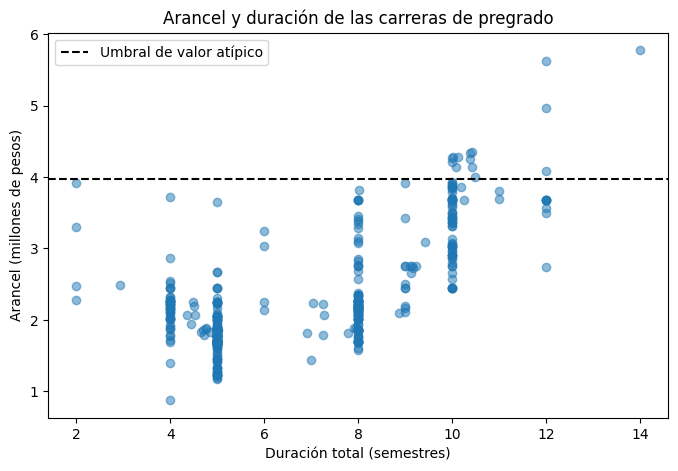

In [57]:
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(carreras['DURACION TOTAL CARRERA (SEMESTRES)'], carreras['VALOR ARANCEL (PESOS)'] / 1000000, alpha=0.5)
ax.axhline(umbral / 1000000, color='black', linestyle='--', label='Umbral de valor atípico')
ax.set_title('Arancel y duración de las carreras de pregrado')
ax.set_xlabel('Duración total (semestres)')
ax.set_ylabel('Arancel (millones de pesos)')
ax.legend()
plt.show()

In [58]:
# Coeficiente de correlación entre duración y arancel (va de -1 a 1)
correlacion = carreras['DURACION TOTAL CARRERA (SEMESTRES)'].corr(carreras['VALOR ARANCEL (PESOS)'])
print("Coeficiente de correlación:", round(correlacion, 2))

Coeficiente de correlación: 0.69


Interpretación:

P25 de las carreras: \$1.780.000. P75: \$2.658.000. Rango intercuartílico: \$878.000.
Umbral de valor atípico: \$3.975.000.

**14 carreras** superan el umbral:

Medicina (U. de Antofagasta): \$5.774.000.
Odontología (U. de Antofagasta): \$5.626.000.
Odontología (U. del Alba): \$4.970.000.
Y 11 carreras de la Universidad Católica del Norte: Ing. Civil Metalúrgica, Ing. Civil de Minas, Geología, Ing. Civil Industrial, Derecho, Ing. Civil, Ing. Comercial, Ing. Civil Química, Ing. Civil en Computación e Informática, Arquitectura e Ing. Civil Ambiental.

**Explicación con las variables de la base:**

- **Duración:** el gráfico muestra que las carreras más largas tienden a tener aranceles más altos. El coeficiente de correlación es 0,69, lo que indica una relación positiva fuerte. Todas las carreras sobre el umbral duran 10 semestres o más. El arancel es anual, por lo que no se trata de un efecto de sumar más semestres: las carreras largas cobran más cada año.
- **Tipo de institución:** 13 de las 14 carreras son de universidades CRUCH, que tienen el arancel mediano más alto (\$3.419.000).
- **Área:** predominan Tecnología (7 carreras) y Salud (3).

**Cambio respecto al criterio anterior.** Antes se comparaba el P75 de los registros (\$3.676.000) con el promedio de carreras agrupadas solo por nombre, lo que mezclaba dos unidades distintas y daba 26 carreras. Con el criterio actual, calculado sobre las carreras, se identifican 14 carreras que se separan claramente de la mayoría.

### Contexto de la Región de Antofagasta

El contexto regional ayuda a interpretar los resultados. La información del Gobierno Regional de Antofagasta señala que la minería tiene un peso predominante en la economía regional.

De las 14 carreras con aranceles sustancialmente más altos, 6 están relacionadas con la minería y la industria extractiva (Ing. Civil de Minas, Metalúrgica, Geología, Química, Ambiental e Industrial). Esto permite relacionar los resultados con el contexto regional de forma descriptiva.

Este contexto no permite afirmar que la actividad minera sea la causa de los mayores aranceles, ya que el análisis realizado no demuestra una relación causal. Además, la duración y el tipo de institución también explican parte de los resultados.

Fuente contextual: Gobierno Regional de Antofagasta, *Política Regional de Integración e Internacionalización de la Región de Antofagasta 2024-2033*, datos económicos regionales 2018–2022.

# 5. Conclusiones

- La base analizada contiene 31.595 registros de matrícula de Educación Superior de la Región de Antofagasta correspondientes a 2021. No tiene registros duplicados; los valores nulos corresponden a instituciones no acreditadas y los valores atípicos son reales, por lo que no se eliminaron datos.
- La distribución por género es equilibrada, con 50,9% femenino y 49,1% masculino.
- Las Universidades CRUCH concentran el 40,4% de los registros y Tecnología es el área con mayor representación (36,7%).
- La edad presenta un promedio de 25,4 años, una mediana de 23 años y una moda de 19 años. La distribución es asimétrica hacia la derecha, por lo que la mediana representa mejor la edad típica.
- La mediana de la matrícula es \$165.000. El arancel promedio es \$2.767.302 por matriculado y \$2.365.188 por carrera.
- La duración presenta dos grupos: carreras técnicas de 4 a 5 semestres y carreras profesionales de 8 a 10 semestres.
- Considerando cada carrera una vez, Ciencias Básicas, Derecho y Salud tienen carreras más caras que el promedio. Tecnología y Arte y Arquitectura están en torno al promedio.
- Los estudiantes que ingresan a Universidades CRUCH son más jóvenes (mediana 19 años) que los que ingresan a Universidades Privadas e Institutos Profesionales (medianas de 24 y 23 años). Es una asociación descriptiva, no una relación causal.
- 14 carreras tienen aranceles sustancialmente más altos. Son carreras largas, principalmente de universidades CRUCH y varias relacionadas con la minería.
- La unidad de análisis debe definirse según la pregunta: contar matriculados o carreras puede cambiar la conclusión.